#Baixando base de Dados

Link da base de dados: https://www.kaggle.com/datasets/mirichoi0218/insurance

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mirichoi0218/insurance")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'insurance' dataset.
Path to dataset files: /kaggle/input/insurance


##Listando o diretório para ver arquivos:

Verificação dos dados no Colab e terminal Linux: "!ls" roda os arquivos presentes no colab:

In [ ]:
!ls {path}

insurance.csv


Modo mais geral de verificar todos os aqruivos:

In [ ]:
import os

os.listdir(path)

['insurance.csv']

Looping para verificar os caminhos dos arquivos

In [ ]:
for files in os.listdir(path):
  print(os.path.join(path, files))

/kaggle/input/insurance/insurance.csv


In [ ]:
for root, dirs, files in os.walk(path):
  for file in files:
    print(os.path.join(root, file))

/kaggle/input/insurance/insurance.csv


In [ ]:
import pandas as pd

dados = pd.read_csv('/kaggle/input/insurance/insurance.csv')

dados

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


#EDA - Exploratory Data Analysis

In [ ]:
dados.info()
print('\n')
dados.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB




,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
dados.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
dados.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
dados[dados.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


Não há valores nulos a serem tratados.

Distribuição gráfico de frequências das idades da base de dados:

Pela regra de Sturges:

In [ ]:
import numpy as np

k = np.ceil(1 + np.log2(len(dados['age'])))
k = k.astype(np.int64)
intervalos = pd.cut(dados['age'].copy(), bins = k, right = False, include_lowest = True)
intervalos.value_counts().sort_index()

,count
age,
"[18.0, 21.833)",194
"[21.833, 25.667)",112
"[25.667, 29.5)",111
"[29.5, 33.333)",106
"[33.333, 37.167)",101
"[37.167, 41.0)",77
"[41.0, 44.833)",108
"[44.833, 48.667)",116
"[48.667, 52.5)",115


Utilizando a regra de Sturges as divisões das faixas de idade ficou muito grandes (com 12 faixas). Portanto, a divisão de idades serão feitas de forma manual em faixas selecionadas:

In [ ]:
lim = [18, 24, 30, 36, 42, 48, 54, 60, 65]

faixas = pd.cut(dados['age'].copy(), bins = lim, right = False, include_lowest = True)
freq = faixas.value_counts()
freq_rel = faixas.value_counts(normalize = True)
porctg = faixas.value_counts(normalize=True) * 100

tab_freq = pd.DataFrame({'Frequência': freq, 'Frequência Relativa': round(freq_rel,2), 'Porcentagem': round(porctg, 2)}).sort_index()
tab_freq.rename_axis('Idade')

tab_freq

,Frequência,Frequência Relativa,Porcentagem
age,,,
"[18, 24)",250,0.19,18.68
"[24, 30)",167,0.12,12.48
"[30, 36)",157,0.12,11.73
"[36, 42)",154,0.12,11.51
"[42, 48)",168,0.13,12.56
"[48, 54)",172,0.13,12.86
"[54, 60)",156,0.12,11.66
"[60, 65)",114,0.09,8.52


In [ ]:
import matplotlib.pyplot as plt

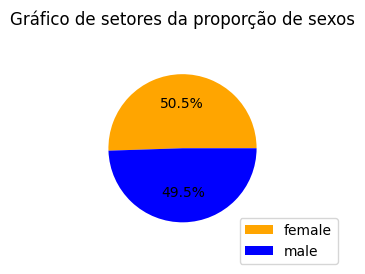

In [ ]:
fig, ax = plt.subplots(figsize = (3, 3))
ax.set_title('Gráfico de setores da proporção de sexos')
ax.pie(dados['sex'].value_counts(), autopct = '%1.1f%%', colors = ['orange', 'blue'], radius = 0.8)
ax.legend(list(dados['sex'].unique()), loc = 'center right', bbox_to_anchor = (1.2, 0.1), frameon = True)
plt.tight_layout()
plt.show()

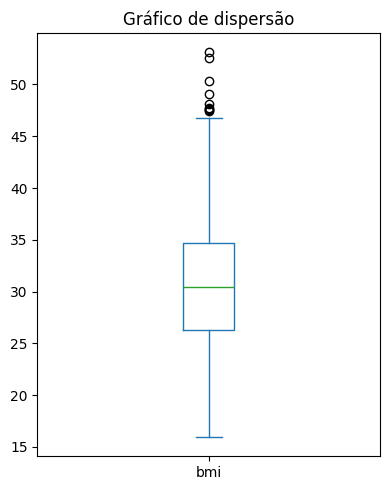

In [ ]:
graf_disp1 = dados['bmi'].plot.box(figsize=(4,5))
plt.title('Gráfico de dispersão')
plt.tight_layout()
plt.show()

Os dados de BMI apresentam uma distribuição relativamente bem simétrica, com alguns outliers

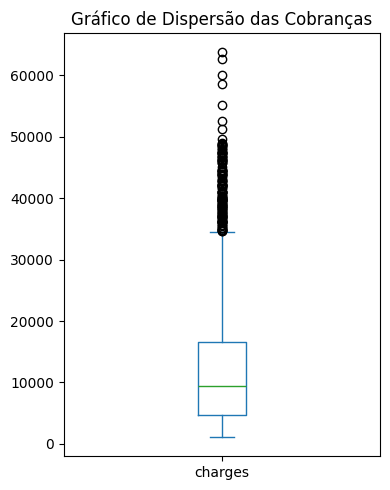

In [ ]:
box2 = dados['charges'].plot.box(figsize=(4, 5))
plt.title('Gráfico de Dispersão das Cobranças')
plt.tight_layout()
plt.show()

In [ ]:
from scipy import stats

iqr = stats.iqr(dados['charges'])

q1, q3 = np.percentile(dados['charges'], [25, 75])
limite_inf = q1 - 1.5 * iqr
limite_sup = q3 + 1.5 * iqr

outliers = dados[(dados['charges'] < limite_inf) | (dados['charges'] > limite_sup)]
len(outliers)

139

Coeficiente de correlação Ponto-Bisserial (point–biserial correlation):

Trata-se de um coeficiente de correlação calculado entre uma variável dicotômica Y (binária), e uma variável contínua X, indicada para situações em que uma variável binária com uma contínua.

Fórmula:

$$r_{pb} = \frac{\overline{Y}_1 - \overline{Y}_0}{s_y} \sqrt{\frac{N_0 N_1}{N(N - 1)}}$$

Onde $\overline{Y}_0$ e $\overline{Y}_1$ são as médias das observações métricas contínuas quando a variável discreta se iguala a 0 e 1, respectivamente; $N_0$ e $N_1$ são o número de observações codificadas como 0 e 1 respectivamente;
$N$ é o número total de observações e $s_y$ é o desvio padrão de todas as observações métricas.


In [ ]:
from scipy import stats

fumo = dados['smoker'].map({'no': 0, 'yes': 1})

sexo = dados['sex'].map({'female': 0, 'male': 1})

corr_biserial_fumo = stats.pointbiserialr(fumo, dados['charges'])

corr_biserial_fumo

SignificanceResult(statistic=np.float64(0.7872514304984773), pvalue=np.float64(8.271435842177446e-283))

In [ ]:
corr_biserial_sex = stats.pointbiserialr(sexo, dados['charges'])

corr_biserial_sex

SignificanceResult(statistic=np.float64(0.05729206220202537), pvalue=np.float64(0.036132721005929666))

In [ ]:
a = dados.copy()
a['smoker'] = a['smoker'].map({'no':0, 'yes': 1})
a['sex'] = a['sex'].map({'female': 0, 'male': 1})

a.drop('region', axis=1, inplace = True)

corr = a.corr(method= 'pearson', min_periods = 1)
corr

,age,sex,bmi,children,smoker,charges
age,1.000000,-0.020856,0.109272,0.042469,-0.025019,0.299008
sex,-0.020856,1.000000,0.046371,0.017163,0.076185,0.057292
bmi,0.109272,0.046371,1.000000,0.012759,0.003750,0.198341
children,0.042469,0.017163,0.012759,1.000000,0.007673,0.067998
smoker,-0.025019,0.076185,0.003750,0.007673,1.000000,0.787251
charges,0.299008,0.057292,0.198341,0.067998,0.787251,1.000000


Apesar do cuidado especial no cálculo dos coeficientes de correlação entre as variáveis binárias (sex e smoker) com as variáveis contínuas (bmi, charges, ...) pelo método Ponto-Bisserial (o qual é ideal para esses tipos de variáveis), a utilização do método genérico de cálculo da matriz de correlação por Pearson, pela documentação Pandas, não apresentou diferença de resultado.

Inclusive, a correlação de Pearson tem o seu coeficiente $r_{xy}$ para uma amostra expresso  na forma:

$$r_{xy} = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}
{\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2} \sqrt{\sum_{i=1}^{n} (y_i - \bar{y})^2}}$$

Isso, dado um conjunto de dados pareados $\{(x_1, y_1), \ldots, (x_n, y_n)\}$ composto por $n$ pares.

onde:

- $n$ é o tamanho da amostra;
- $x_i, y_i$ são os pontos individuais da amostra indexados por $i$;
- $\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i$ (a média amostral), e analogamente para $\bar{y}$.

É interessante também analisar como que os dados de "charges" variam por região (se é que realmente variam).

In [ ]:
regioes = dados['region'].unique()

regioes

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

Sendo convidativo realizar o teste de ANOVA de "region" por "charges", para esse teste ter alguma consistência, espera-se que os dados atendam esses três pressupostos:

1) Independência: As observações devem ser independentes entre si.

2) Normalidade dos erros: Os dados dentro de cada grupo (ou, mais precisamente, os resíduos do modelo) devem seguir uma distribuição normal. A ANOVA é relativamente robusta a violações leves, especialmente com amostras grandes.

3) Homogeneidade das Variâncias (Homocedasticidade): As variâncias dos dados dentro de cada grupo devem ser aproximadamente iguais. Isso significa que a variabilidade dos dados deve ser consistente entre as diferentes condições ou tratamentos.



A seguir, serão investigadas se os dados de "charges" atendem aos citados pressupostos.

1) As amostras são aleatórias e independentes: Pelo contexto da base de dados e sua forma sabe-se que não há dependência temporal nem espacial entre os dados, e ao que parece, os dados foram criados com a intenção de simularem amostras aleatórias e independentes.

☑ ***As amostras são aleatórias e independentes***

2) As populações têm distribuição normal (o teste é paramétrico): Dessa hipótese em diante torna-se necessário fazer algumas análises.

In [ ]:
print('Estatística de insumos nas diferentes regiões\n')

for i, regiao in enumerate(regioes):
  Regiao = dados[dados['region'] == regiao]
  insumos = dados[dados['region'] == regiao]['charges']
  print(f'{i+1}. {regiao}: Contagem: {len(Regiao)}   Média: {np.mean(insumos):.2f}   Mediana: {np.median(insumos):.2f}   Desvio Padrão: {np.std(insumos):.2f}')

Estatística de insumos nas diferentes regiões

1. southwest: Contagem: 325   Média: 12346.94   Mediana: 8798.59   Desvio Padrão: 11539.39
2. southeast: Contagem: 364   Média: 14735.41   Mediana: 9294.13   Desvio Padrão: 13951.89
3. northwest: Contagem: 325   Média: 12417.58   Mediana: 8965.80   Desvio Padrão: 11055.23
4. northeast: Contagem: 324   Média: 13406.38   Mediana: 10057.65   Desvio Padrão: 11238.42


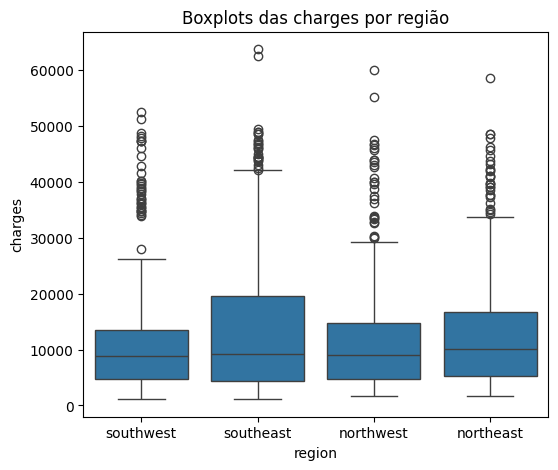

In [ ]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(x=dados['region'], y=dados['charges'], ax = ax)
ax.set_title('Boxplots das charges por região')
plt.show()

Observando os box plots por região, é possível observar uma relativa assimetria em todas as regiões com alguns outliers. A região com maior assimetria é a região "southeast", e a que apresenta a maior quantidade de outliers é a região "southwest".

In [ ]:
from scipy import stats

total = 0

for i, regiao in enumerate(regioes):
  dados_regiao = dados[dados['region'] == regiao]['charges']
  iqr = stats.iqr(dados_regiao)
  q1, q3 = np.percentile(dados_regiao, [25, 75])
  limite_inf = q1 - 1.5 * iqr
  limite_sup = q3 + 1.5 * iqr
  outliers = dados_regiao[(dados_regiao < limite_inf) | (dados_regiao > limite_sup)]
  total += len(outliers)
  print(f'{i+1}. Quantidade de Outliers da região {regiao}: {len(outliers)}')

print(total)


1. Quantidade de Outliers da região southwest: 38
2. Quantidade de Outliers da região southeast: 26
3. Quantidade de Outliers da região northwest: 29
4. Quantidade de Outliers da região northeast: 29
122


A mérito de curiosidade, verifica-se abaixo que forma a distribuição os dados levam por região.

<function matplotlib.pyplot.show(close=None, block=None)>

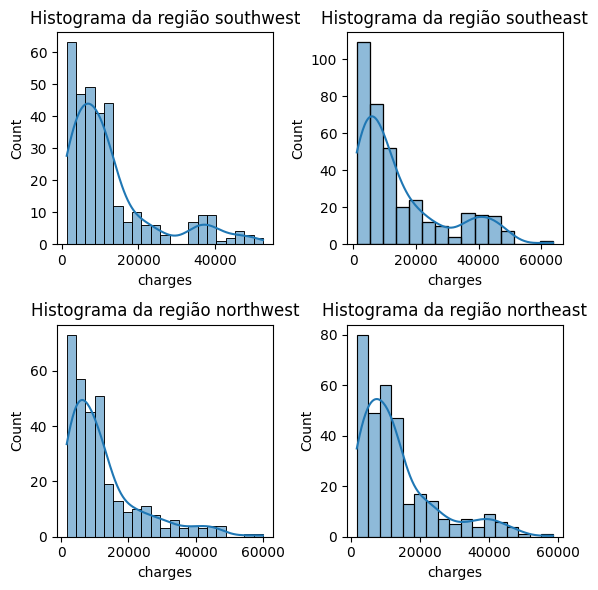

In [ ]:
lista_regioes = list(regioes)

fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize=(6, 6))
axes = axes.flatten()

for i, regiao in enumerate(lista_regioes):
  df_regiao = dados[dados['region'] == f'{regiao}']['charges']
  sns.histplot(df_regiao, kde = True, ax = axes[i])
  axes[i].set_title(f'Histograma da região {regiao}')

plt.tight_layout()
plt.show

In [ ]:
ddos = dados.copy()
variaveis = ddos.pop('charges')
regioes = ddos.pop('region')
data = pd.concat([variaveis, regioes], axis=1)
data

,charges,region
0,16884.92400,southwest
1,1725.55230,southeast
2,4449.46200,southeast
3,21984.47061,northwest
4,3866.85520,northwest
...,...,...
1333,10600.54830,northwest
1334,2205.98080,northeast
1335,1629.83350,southeast
1336,2007.94500,southwest


A normalidade deve ser observada na distribuição dos resíduos derivados do modelo de regressão simples feito para o teste ANOVA.

O que ocorre é que o teste ANOVA é um caso particular da regressão linear em que a variável resposta contínua ("charges"), e a(s) variável(is) explicativa(s) categóricas ("region"), representadas por variáveis indicadoras (dummies), e o objetivo é testar se os coeficientes associados aos grupos são iguais.

In [ ]:
import statsmodels.formula.api as smf

modelo_anova = smf.ols('(charges) ~ C(region)', data = data).fit()

residuos = modelo_anova.resid

residuos

,0
0,4537.986623
1,-13009.859138
2,-10285.949438
3,9566.895236
4,-8550.720174
...,...
1333,-1817.027074
1334,-11200.403716
1335,-13105.577938
1336,-10338.992377


###Modelo Linear da ANOVA (statsmodels.formula.api.ols)

A ANOVA de um fator pode ser formulada como um modelo de regressão linear, no qual a variável resposta é explicada por uma variável categórica. Esse modelo é dado por:

$$Y_{ij} = \mu + \tau_i + \varepsilon_{ij}$$

Onde:

$Y_{ij}$: Observação $j$ do grupo $i$

$μ$: média geral
$𝜏_{i}$: efeito do grupo $i$

$ε_{ij}$: erro aleatório, com $𝜀_{𝑖𝑗}∼𝑁(0,𝜎^{2})$

Restrição de identificabilidade:

$$\sum_{i=1}^{k} \tau_i = 0$$

Na forma matricial:

$$\mathbf{Y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}$$

Onde:

$𝑋$: matriz de design (codificação da variável categórica)

$𝛽$: vetor de parâmetros

$𝜀∼𝑁(0,𝜎^{2}𝐼)$

**Hipóteses testadas no modelo linear da ANOVA:**

$H_0 \rightarrow β_1 = β_2 = β_3 = 0$

$H_1 \rightarrow$ Pelo menos uma média difere

O que é equivalente a:

$H_0 \rightarrow μ_{SW} = μ_{SE} = μ_{NW} = μ_{NE}$

$H_1 \rightarrow$ Pelo menos uma média difere

In [ ]:
ANOVA = modelo_anova.params

ANOVA

,0
Intercept,13406.384516
C(region)[T.northwest],-988.809142
C(region)[T.southeast],1329.026921
C(region)[T.southwest],-1059.447139


In [ ]:
a = ANOVA.iloc[0]
b = ANOVA.iloc[1]
c = ANOVA.iloc[2]
d = ANOVA.iloc[3]
print(a + d)

12346.937377292325


In [ ]:
print(f'Equação do modelo linear do teste ANOVA: y = {ANOVA.iloc[0]:.2f} + ({ANOVA.iloc[1]:.2f})*D_1 + ({ANOVA.iloc[2]:.2f})*D_2 + ({ANOVA.iloc[3]:.2f})*D_3')

Equação do modelo linear do teste ANOVA: y = 13406.38 + (-988.81)*D_1 + (1329.03)*D_2 + (-1059.45)*D_3


**Intercepto (13406.38) → Média do grupo base (northeast)**

**-988.81 → Quanto northeast está acima de northwest**

**1329.03 → Quanto northeast está abaixo de southeast**

**-1059.45 → Diferença entre northeast e southwest**

**Substituindo as dummies**:

**northeast**: $𝑌 = 13406.38$

**northwest**: $𝑌 = 13406.38 - 988.81 = 12417.58$

**southeast**: $𝑌 = 13406.38 + 1329.03 = 14735.41$

**southwest**: $𝑌 = 13406.38 - 1059.45 = 12346.94$

In [ ]:
print(modelo_anova.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     2.970
Date:                Sun, 26 Apr 2026   Prob (F-statistic):             0.0309
Time:                        18:04:11   Log-Likelihood:                -14473.
No. Observations:                1338   AIC:                         2.895e+04
Df Residuals:                    1334   BIC:                         2.898e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept               1.34

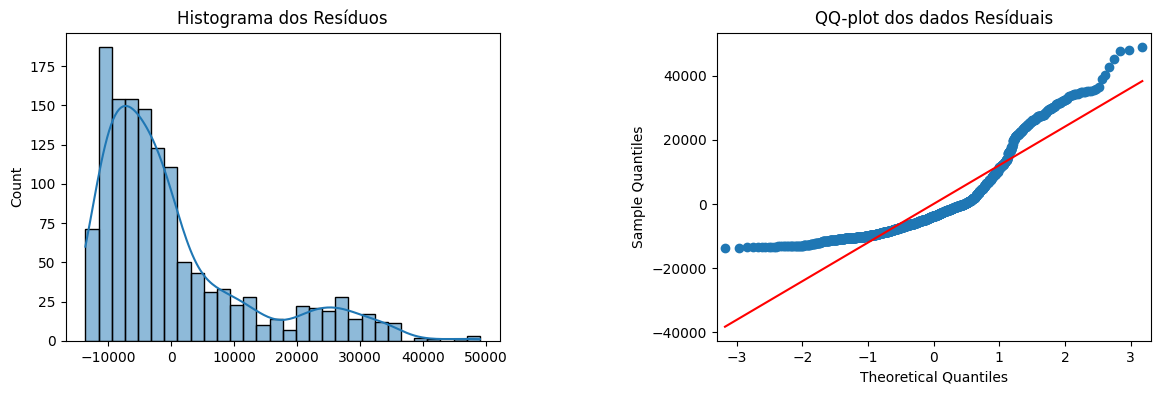

In [ ]:
import statsmodels.api as sm

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14,4))

axes[0].set_title('Histograma dos Resíduos')
sns.histplot(residuos, kde = True, ax = axes[0])

axes[1].set_title('QQ-plot dos dados Resíduais')
sm.qqplot(residuos, line = 's', ax = axes[1])

plt.subplots_adjust(wspace=0.5)
plt.show()

###Outros métodos de análise de normalidade:
---

Descrições:

###***Skewness/Assimetria (stats.skewtest)***
É uma medida estatística que quantifica o quanto que a distribuição da população/amostra se desloca em torno da sua média.

$$ \mu_3 = \frac{\mu_3}{σ^{3}} = \frac{\sum_{i=1}^{N}{(X_i - \bar{X})}^{3}}{(N-1)σ^{3}}$$

Assimetria Positiva (à direita): A cauda do lado direito é mais longa; a média e a mediana são maiores que a moda.

Assimetria Negativa (à esquerda): A cauda do lado esquerdo é mais longa; a média e a mediana são menores que a moda.

Assimetria Zero: A distribuição é perfeitamente simétrica, onde média, mediana e moda coincidem.

$Hipóteses$ $do$ $stats.skewtest$:

$H_0 \rightarrow$ Assimetria da população/amostra é de uma distribuição normal

$H_1 \rightarrow$ Assimetria da população/amostra **não** é de uma distribuição normal


###***Curtose (stats.kurtosistest)***:
Mensura o decaimento das caudas da distribuição em relação a uma medida de posição central (média ou mediana), podendo haver decaimento lento (caldas com alta densidade) ou abrupto (densidade baixa nas caldas).

$$K = \frac{\mu_4}{σ^{4}} = \frac{\frac{1}{N}\sum_{i=1}^{N}{(X_i - \bar{X})}^{4}}{σ^{4}}$$

Mesocúrtica (Normal): A curva normal possui curtose de 3 (ou excesso de 0), servindo como referência.

Leptocúrtica (Pico alto): Curva com pico alto e caudas pesadas (curtose > 3). Indica alta concentração de dados ao redor da média e maior presença de outliers.

Platicúrtica (Achatada): Curva com pico baixo (caso haja) e caudas leves (curtose < 3). Os dados são mais espalhados.

$Hipóteses$ $do$ $stats.kurtosistest$:

$H_0 \rightarrow$ A curtose da população da qual a amostra foi extraída é a da distribuição normal.

$H_1 \rightarrow$ A curtose da população da qual a amostra foi extraída **não** é a de uma distribuição normal.

###***K² de D'Agostino (stats.normaltest)***:
É um teste que analisa mutuamente a curtose e o skewness (assimetria), para avaliar normalidade.

$$D'Agostino = k^{2} + s^{2}$$

$Hipóteses$ $do$ $stats.normaltest$:

$H_0 \rightarrow$ A amostra provém de uma distribuição normal.

$H_1 \rightarrow$ A amostra **não** provém de uma distribuição normal.

###***Shapiro–Wilk (stats.shapiro)***:
Teste de normalidade da estatística frequentista. Classicamente esse método funciona com bases de até 50 dados, atualmente esse método pode ser aplicadoo até 5000 dados com uma pequena perda de precisão do p-valor.

$$W = \frac{(\sum_{i=1}^{N}{a_iX_{(i)}})^{2}}{\sum_{i=1}^{N}{(X_i - \bar{X})^{2}}}$$

Onde

$X_{(i)}$: Com parênteses envolvendo o índice subscrito i é a i-ésima estatística de ordem, ou seja, o i-ésimo menor número na amostra (não confundir com $X_{i}$).

$a_i$ é dado por: $$(a_1, ..., a_n) = \frac{m^{T}V^{-1}}{C}$$

Onde $C$ é uma norma vetorial: $$C = \|V^{-1}m\| = \sqrt{m^{T}V^{-1}V^{-1}m}$$

$m$ é vetor de valores esperados das estatísticas de ordem de variáveis aleatórias independentes e identicamente distribuídas, amostradas da distribuição normal padrão

$$m = (m_1, ..., m_n)^{T}$$

E $V$ é a matriz de covariância dessas estatísticas de ordem normais.

$$V = Cov(Z_{(i)}, Z_{(j)})$$

$Hipóteses$ $do$ $stats.shapiro$:

$H_0 \rightarrow$ Os dados foram extraídos de uma distribuição normal.

$H_1 \rightarrow$ A amostra **não** provém de uma distribuição normal.

###***Teste Kolmogorov-Smirnov (stats.kstest)***:

O teste de Kolmogorov-Smirnov compara a função de distribuição empírica $F_n(x)$ com uma distribuição teórica $F(x)$, medindo a maior distância entre as distribuições.


$$D = \sup_x |F_n(x) - G(x)|$$

$Hipóteses$ $do$ $stats.kstest$:

$H_0 \rightarrow$ $F_n(x) = F(x)$, ou seja, os dados seguem a distribuição especificada.

$H_1 \rightarrow$ $F_n(x) \neq F(x)$, ou seja, os dados **não** seguem a distribuição especificada.

###***Teste Anderson-Darling (stats.anderson)***:

O teste de Anderson–Darling é um teste de aderência à normalidade que dá maior peso às caudas da distribuição. Útil quando se deseja detectar desvios da normalidade em regiões extremas da amostra. Quanto maior a estatística do teste, maior a evidência contra a hipótese de normalidade.

$$ A^2 = -n - \frac{1}{n} \sum_{i=1}^{n} (2i - 1)\left[\ln F(x_i) + \ln(1 - F(x_{n+1-i}))\right]$$

É mais sensível a desvios nas extremidades.

$Hipóteses$ $do$ $stats.anderson$:

$H_0 \rightarrow$ A amostra é extraída de uma população que segue uma distribuição específica.

$H_1 \rightarrow$ A amostra **não** é extraída de uma população que segue uma distribuição específica.

###***Teste Lilliefors (stats.lilliefors)***:

O teste de Lilliefors é uma adaptação do teste de Kolmogorov–Smirnov para situações em que a média e o desvio-padrão da distribuição normal são estimados a partir da própria amostra. Ele é, portanto, mais apropriado do que o KS clássico quando os parâmetros da normalidade não são previamente conhecidos.

$$D = \sup_x \left| F_n(x) - \hat{F}(x) \right|$$

$Hipóteses$ $do$ $stats.lilliefors$:

$H_0 \rightarrow$ A distribuição é normal ou exponencial.

$H_1 \rightarrow$ A distribuição **não** é normal ou exponencial.

In [ ]:
Skewness = stats.skewtest(residuos)
print(f'Skewness: z-score(s): {Skewness[0]:.3f}, p-value: {Skewness[1]}.')
Kurtosis = stats.kurtosistest(residuos)
print(f'\nCurtose: z-score(k): {Kurtosis[0]:.3f}, p-value: {Kurtosis[1]}.')
normalteste = stats.normaltest(residuos)
print(f'\nTeste D\'Agostino: s² + k²: {normalteste[0]:.3f}, p-value: {normalteste[1]}.')

Skewness: z-score(s): 16.708, p-value: 1.1419435566431723e-62.

Curtose: z-score(k): 6.945, p-value: 3.796709876629375e-12.

Teste D'Agostino: s² + k²: 327.391, p-value: 8.088507151011067e-72.


O teste de Skewness revela uma assimetria à direita dos dados de resíduos, com o p-valor rejeitando a hipótese nula de se tratar de uma distribuição normal. A curtose aponta curva alta e picos pesados (essa segunda característica não é observada no histograma da distribuição dos resíduos), e o p-valor de novo rejeita normalidade, como também ocorre no teste D'Agostino.

In [ ]:
Shapiro = stats.shapiro(residuos)

print(f'Teste de Shapiro Wilk:\nstatistic: {Shapiro[0]:.3f}, p-value: {Shapiro[1]}.')

Teste de Shapiro Wilk:
statistic: 0.827, p-value: 1.0804713220097883e-35.


In [ ]:
Ks_test = stats.kstest(residuos, 'norm', args=(residuos.mean(), residuos.std(ddof=1)))
print('Teste Kolmogorov-Smirnov:')
Ks_test

Teste Kolmogorov-Smirnov:


KstestResult(statistic=np.float64(0.18378157304994602), pvalue=np.float64(5.020088535489606e-40), statistic_location=np.float64(341.4878336141792), statistic_sign=np.int8(1))

In [ ]:
from statsmodels.stats.diagnostic import lilliefors

lfors = lilliefors(residuos, dist='norm')

print(f'Teste Lilliefors:\nstatistic: {lfors[0]:.3f}, p-value: {lfors[1]}.')

Teste Lilliefors:
statistic: 0.184, p-value: 0.0009999999999998899.


In [ ]:
print('Teste Anderson-Darling:')
stats.anderson(residuos, dist='norm')

Teste Anderson-Darling:


AndersonResult(statistic=np.float64(79.69566195664379), critical_values=array([0.574, 0.654, 0.785, 0.915, 1.089]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(-1.2180975378005138e-11), scale=np.float64(12069.775385283774))
 success: True
 message: '`anderson` successfully fit the distribution to the data.')

###Conclusão dos testes de normalidade:
---


Todos os métodos apresentam um p-valor muito inferior que 0.05, rejeitando fortemente assim as hipóteses nulas de normalidade dos resíduos do modelo de regressão OLS - Ordinary Least Squares (mínimos quadrados ordinários).

O teste de Kolmogorov-Smirnov apresenta um alto valor no seu resultado de "statistic_location=np.float64(341.4878336141792)", alegando uma grande distância entre a função de distribuição dos resíduos e a função de distribuição cumulativa normal. O resultado positivo "statistic_sign=np.int8(1)" revela uma diferença positiva máxima entre a função de distribuição empírica que excede a função de distribuição cumulativa hipotética.

***Os resíduos não tem distribuição normal***

###Verificando Homocedasticidade entre as diferentes regiões da base de dados:
---

###***Teste Levene (stats.levene)***:

Estatística inferencial usada para avaliar a igualdade de variâncias de uma variável calculada para dois ou mais grupos. É mais robusto do que o teste de Bartlett quando os dados não seguem perfeitamente a normalidade.

$$ W = \frac{(N - k)}{(k - 1)} \cdot
\frac{\sum_{i=1}^{k} n_i (Z_{i\cdot} - Z_{\cdot\cdot})^2}
{\sum_{i=1}^{k} \sum_{j=1}^{n_i} (Z_{ij} - Z_{i\cdot})^2}$$

Onde:

$k$ é o número de grupos diferentes aos quais os casos amostrados pertencem.

$N_{i}$ é o número de casos $iº$ grupo.

$N$ é o número total de casos em todos os grupos.

$Z_{ij} = \begin{cases} |Y_{ij} - \bar{Y}_{i \cdot}|, & \bar{Y}_{i \cdot} \text{ é a média do grupo } i, \\ |Y_{ij} - \tilde{Y}_{i \cdot}|, & \tilde{Y}_{i \cdot} \text{ é uma mediana do grupo } i. \end{cases}$

(Ambas as definições estão em uso, embora a segunda seja, estritamente falando, o teste de Brown-Forsythe).

$Y_{ij}$ é o valor da variável medida para o $jº$ caso do $iº$ grupo.

$Hipóteses$ $do$ $stats.levene$:

$H_0 \rightarrow$ As amostras de entrada são provenientes de populações com variâncias iguais.

$H_1 \rightarrow$ As amostras de entrada **não** são provenientes de populações com variâncias iguais.


###***Teste Bartlett (stats.bartlett)***:
Avalia a homogeneidade de variâncias entre grupos. Sensível a desvios de normalidade, Ou seja, se as amostras vierem de distribuições não normais, o teste de Bartlett pode simplesmente estar testando a não normalidade.

Este procedimento de teste baseia-se na estatística cuja distribuição amostral é aproximadamente uma distribuição Qui-Quadrado com $(k − 1)$ graus de liberdade, onde k é o número de amostras aleatórias, que podem variar em tamanho e são extraídas de distribuições normais independentes. Sendo $i \in 1 : k$:

$$ \chi^2 = \frac{(N - k) \ln(S_p^2) - \sum_{i=1}^k (n_i - 1) \ln(S_i^2)}{1 + \frac{1}{3(k-1)} \left( \sum_{i=1}^k \left( \frac{1}{n_i - 1} \right) - \frac{1}{N-k} \right)} $$

A estatística do teste tem aproximadamente uma distribuição $\chi_{k-1}^2$. Assim, a hipótese nula é rejeitada se $\chi^2 > \chi_{k-1,\alpha}^2$ (onde $\chi_{k-1,\alpha}^2$ é o valor crítico da cauda superior para a distribuição $\chi_{k-1}^2$).

Onde:

$k$ são as variâncias populacionais.

$n_i$ são amostras dessa população. Com $N = \sum_{i=1}^k n_i$


$S_i^2$ são as variâncias amostrais

$S_p^2 = \frac{1}{N - k} \sum_{i} (n_i - 1)S_i^2$ Esse termo é da estimativa combinada para a variância.

$Hipóteses$ $do$ $stats.bartlett$:

$H_0 \rightarrow$ As amostras de entrada são provenientes de populações com variâncias iguais.

$H_1 \rightarrow$ As amostras de entrada **não** são provenientes de populações com variâncias iguais.

###***Teste Fligner-Killeen (stats.fligner)***:
É um teste não paramétrico para homogeneidade de variâncias, ideal quando os dados não seguem uma distribuição normal ou contêm outliers. Ele é baseado na mediana e é menos sensível a violações de normalidade do que testes paramétricos, como o de Bartlett.

Esse método é baseado em ranks das transformações logarítmicas dos desvios.

$$X^2 = \frac{\sum_{i=1}^{k} n_i (\bar{R}_i - \bar{R})^2}{\sigma_R^2}$$

Onde:

$\bar{R}_i$ é a média dos ranks do grupo $i$.

$\sigma_R^2$ é a variância dos ranks.

$Hipóteses$ $do$ $stats.bartlett$:

$H_0 \rightarrow$ As amostras de entrada são provenientes de populações com variâncias iguais.

$H_1 \rightarrow$ As amostras de entrada **não** são provenientes de populações com variâncias iguais.


In [ ]:
sample1 = data[data['region'] == 'southwest']['charges']
sample2 = data[data['region'] == 'southeast']['charges']
sample3 = data[data['region'] == 'northwest']['charges']
sample4 = data[data['region'] == 'northeast']['charges']

grupos = [sample1, sample2, sample3, sample4]

Levene = stats.levene(*grupos)

print(f'Teste Levene:\nstatistic: {Levene[0]:.3f}, p-value: {Levene[1]}.')

Teste Levene:
statistic: 5.560, p-value: 0.0008610590250786703.


In [ ]:
Bartlett = stats.bartlett(sample1, sample2, sample3, sample4)

print(f'Teste Bartlett:\nstatistic: {Bartlett[0]:.3f}, p-value: {Bartlett[1]}.')

Teste Bartlett:
statistic: 25.883, p-value: 1.0092988086653104e-05.


In [ ]:
Fligner = stats.fligner(sample1, sample2, sample3, sample4)

print(f'Teste Fligner:\nstatistic: {Fligner[0]:.3f}, p-value: {Fligner[1]}.')

Teste Fligner:
statistic: 19.233, p-value: 0.00024472311448757954.


###Conclusão dos testes de Homocedasticidade:
---

todos os testes apresentaram p-valor inferior a 0.05, o que expressa uma rejeição da hipótese nula de que os grupos apresentam mesma variância, fato que já se era esperado ao analisar rapidamente os gráficos de Box plots dos dados de charges das diferentes regiões da base de dados.

**Não há homocedasticidade entre os dados de insumos das diferentes regiões da base de dados**

### Aplicação dos Testes de Anova:
---

Apesar dos pressupostos de normalidade dos resíduos, e homocedasticidade dos grupos não terem se manifestado na base de dados, ainda sim, será realizado a seguir o teste ANOVA clássico, pois esse teste ainda apresenta robustez quanto a não normalidade dos resíduos, apresentando problemas maiores quando ocorre significativa heterocedasticidade entre os dados dos diferentes grupos. Para contornar esse problema, será utilizado um modelo alternativo do teste Welch ANOVA que não assume variâncias iguais.

###*One-Way* ANOVA (anova_lm, stats.f_oneway)
O teste compara as médias de três ou mais grupos independentes para determinar se pelo menos uma delas é estatisticamente diferente das demais. O teste utiliza a estatística F (razão entre a variância entre grupos e dentro dos grupos)

**Soma dos quadrados total:**

$$SQ_{Tot} = SQ_{Den} + SQ_{Ent}$$

$$SQ_{Tot} = \sum_{i=1}^{k} \sum_{j=1}^{n_i} (Y_{ij} - \bar{Y})^2$$

Essa soma avalia a variabilidade total como a variabilidade entre grupos + variabilidade dentro dos grupos

**Soma de quadrados entre grupos:** Mede o quanto as médias dos grupos diferem da média global

$$SQ_{Ent} = \sum_{i=1}^{k} n_i (\bar{Y}_i - \bar{Y})^2$$

**Soma de quadrados dentro dos grupos:** Mede o quanto os dados variam dentro de cada grupo

$$SQ_{Den} = \sum_{i=1}^{k} \sum_{j=1}^{n_i} (Y_{ij} - \bar{Y}_i)^2$$

quadrado médio total:

$$QM_{Tot} = \frac{SQ_{Tot}}{n-1}$$

quadrado médio entre grupos:

$$QM_{Ent} = \frac{SQ_{Den}}{k-1}$$


quadrado médio dentro (ou residual) dos grupos:

$$QM_{Den} = \frac{SQ_{Ent}}{n-k}$$

**Estatística de teste F**: Mede se a variabilidade explicada pelo modelo é grande em relação ao erro.

$$F = \frac{QM_{Ent}}{QM_{Den}} = \frac{SQ_{Ent}/(k-1)}{SQ_{Den}/(n-k)}$$

Compara a variação entre grupos (diferença entre médias) com relação a variação dentro dos grupos (dispersão dos dados).

Onde:

$𝑘$: número de grupos

$n$: número total de observações

As possíveis análises são:

*   $𝐹 ≈ 1 →$ grupos semelhantes
*   $𝐹$ $_$pequeno $→$ pouca evidência contra $𝐻_0$
*   $𝐹 ≫ 1 →$ diferenças entre grupos

In [ ]:
anova = stats.f_oneway(*grupos, axis=0, equal_var=False, nan_policy='propagate', keepdims=False)

anova

F_onewayResult(statistic=np.float64(2.6080680755736956), pvalue=np.float64(0.0505927632193392))

In [ ]:
anova_True = stats.f_oneway(*grupos, axis=0, equal_var=True,)

anova_True

F_onewayResult(statistic=np.float64(2.96962669358912), pvalue=np.float64(0.0308933560705201))

In [ ]:
from statsmodels.stats.oneway import anova_oneway

welch_anova = anova_oneway(grupos, use_var='unequal', welch_correction=True)

welch_anova

<class 'statsmodels.stats.base.HolderTuple'>
statistic = np.float64(2.6080680755736956)
pvalue = np.float64(0.0505927632193392)
df = (3.0, np.float64(740.957029975374))
df_num = 3.0
df_denom = np.float64(740.957029975374)
nobs_t = np.float64(1338.0)
n_groups = 4
means = array([12346.93737729, 14735.41143761, 12417.57537397, 13406.38451639])
nobs = array([325., 364., 325., 324.])
vars_ = array([1.33568389e+08, 1.95191596e+08, 1.22595316e+08, 1.26693103e+08])
use_var = 'unequal'
welch_correction = True
tuple = (np.float64(2.6080680755736956), np.float64(0.0505927632193392))

In [ ]:
df_anova = sm.stats.anova_lm(modelo_anova, typ=3)

print(df_anova)

                 sum_sq      df           F        PR(>F)
Intercept  5.823289e+10     1.0  398.836043  7.671595e-78
C(region)  1.300760e+09     3.0    2.969627  3.089336e-02
Residual   1.947735e+11  1334.0         NaN           NaN


In [ ]:
df_anova["mean_sq"] = df_anova["sum_sq"] / df_anova["df"]
df_anova

,sum_sq,df,F,PR(>F),mean_sq
Intercept,5.823289e+10,1.0,398.836043,7.671595e-78,5.823289e+10
C(region),1.300760e+09,3.0,2.969627,3.089336e-02,4.335866e+08
Residual,1.947735e+11,1334.0,NaN,NaN,1.460071e+08


###Conclusão dos testes ANOVA:
---

Pela análise exploratória feita nos valores de insumos entre as diferentes regiões da base de dados, sabe-se que as médias entre esses diferentes grupos são diferentes, no entanto, o que o teste ANOVA verifica também é se essas diferenças são grandes o suficiente comparadas à variabilidade interna dos grupos.

Aplicando o modelo linear do teste anova (anova_lm), os resultados foram:

$Teste$ $F$: $2.97$              
$p$-$value = 0.0309$ $< 0.05$

$SQ_{Ent} = 1.300760e+09$

O que faz rejeitar a hipótese nula de que os grupos tem mesma média. O pequeno valor do teste F, aponta uma variabilidade pequena das médias dos diferentes grupos com relação a variabilidade dos grupos.


Já ao aplicar o modelo Welch ANOVA (f_oneway(equal_var=False), anova_oneway) os resultados foram:

$Teste$ $F$: $2.61$              
$p$-$value=0.0506 > 0.05$

O p-valor apresenta um valor limítrofe de não rejeição da hipótese nula, não havendo assim evidência suficiente para afirmar que as médias são diferentes. E o teste F sofreu uma pequena redução que reforça a ideia de uma variabilidade pequena das médias com relação a variabilidade dos próprios grupos. O que provavelmente ocorre é que os dados são tão espalhados que as diferenças entre médias podem ser apenas “ruído”.

O resultado mais confiável para análise de variância são os segundos resultados obtidos pelo método Welch ANOVA, já que testes de homocedasticidade anteriores revelaram heterocedasticidade dos grupos da base de dados.


##Regressão:
---

**Regressão Linear (OLS)** A regressão linear modela a relação entre a variável resposta $y$ e os preditores $X$:

$$y = X\beta + \varepsilon$$

Os coeficientes são estimados pelo método dos mínimos quadrados:

$$\hat{\beta} = (X^TX)^{-1}X^Ty$$

O objetivo é minimizar:

$$\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

###Preparando os dados para Regressão

In [ ]:
dds = dados.copy()

dds['sex'] = dds['sex'].map({'female': 0, 'male': 1})
dds['smoker'] = dds['smoker'].map({'no': 0, 'yes': 1})

dds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   int64  
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   int64  
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(4), object(1)
memory usage: 73.3+ KB


Construindo o modelo de Regressão com somente 5 das 6 variáveis da base de dados:

In [ ]:
#Variável Resposta
y = dds['charges']

X = dds[['age', 'sex', 'bmi', 'children', 'smoker']]

Pré-processando os dados

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 64)

In [ ]:
from sklearn.linear_model import LinearRegression

reg_linear = LinearRegression().fit(X_train, y_train)

y_pred = reg_linear.predict(X_test)

reg_linear.intercept_

np.float64(-12651.682771849217)

In [ ]:
reg_linear.coef_

array([ 2.62619615e+02, -1.41291824e+00,  3.37556964e+02,  5.01420218e+02,
        2.36754546e+04])

In [ ]:
print(f'Equação de Regressão Linear: y = {reg_linear.intercept_:.2f} + ({reg_linear.coef_[0]:.2f})*X_1 + ({reg_linear.coef_[1]:.2f})*X_2 + ({reg_linear.coef_[2]:.2f})*X_3 + ({reg_linear.coef_[3]:.2f})*X_4 + ({reg_linear.coef_[4]:.2f})*X_5')

Equação de Regressão Linear: y = -12651.68 + (262.62)*X_1 + (-1.41)*X_2 + (337.56)*X_3 + (501.42)*X_4 + (23675.45)*X_5


In [ ]:
from sklearn.metrics import r2_score

r22 = r2_score(y_test, y_pred)
r22

0.7621474073365647

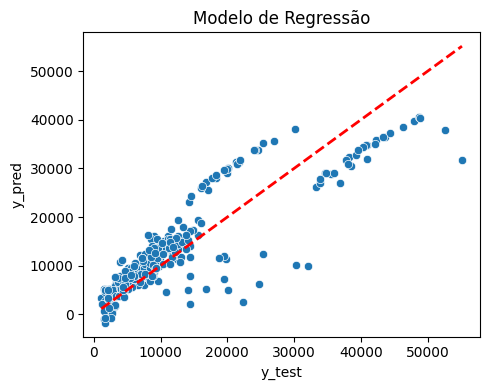

In [ ]:
fig, axes = plt.subplots(figsize = (5, 4))

sns.scatterplot(x = y_test, y = y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')
axes.set_title('Modelo de Regressão')
axes.set_xlabel('y_test')
axes.set_ylabel('y_pred')
plt.tight_layout()
plt.show()

Calculando Resíduos:

In [ ]:
e = (y_test) - (y_pred)

e

,charges
36,-650.365964
436,-1580.421596
1100,-10362.405705
983,11530.077372
672,-2426.921268
...,...
1045,-9776.092685
780,-10382.381903
597,-2407.727896
1139,9917.962840


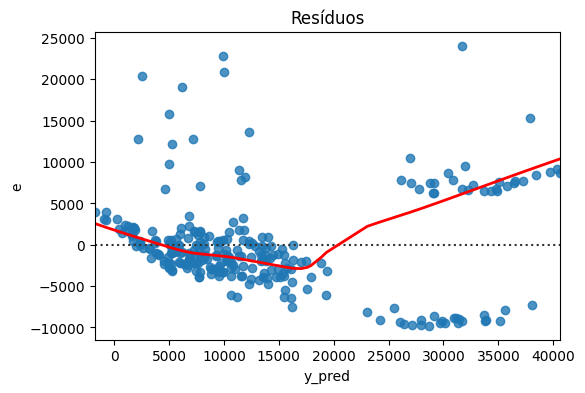

In [ ]:
fig, axes = plt.subplots(figsize = (6, 4))

sns.residplot(x = y_pred, y = e, lowess=True, line_kws={'color': 'red', 'lw': 2})
axes.set_title('Resíduos')
axes.set_xlabel('y_pred')
axes.set_ylabel('e')
plt.tight_layout
plt.show()

Avaliando o desempenho do modelo:

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, median_absolute_error, max_error, mean_absolute_percentage_error

MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = root_mean_squared_error(y_test, y_pred)
MedAE = median_absolute_error(y_test, y_pred)
Max = max_error(y_test, y_pred)
MAPE = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'r2: {r2}\nMAE: {MAE}\nMSE: {MSE}\nRMSE: {RMSE}\nMedAE: {MedAE}\nMax_error: {Max}\nMAPE: {MAPE}')

r2: 0.7621474073365647
MAE: 4092.375722775256
MSE: 32417064.468640897
RMSE: 5693.598551763278
MedAE: 2768.8552727799547
Max_error: 23451.784072706036
MAPE: 0.43809293678551436


###Métricas de Avaliação
---

**Coeficiente de Determinação ($R^2$)**

$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

Mede a proporção da variância explicada pelo modelo.

**Erro Absoluto Médio (MAE)**

$$MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

Mede o erro médio absoluto.

**Erro Quadrático Médio (MSE)**

$$MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

Penaliza mais erros grandes.

**Raiz do Erro Quadrático Médio (RMSE)**

$$RMSE = \sqrt{MSE}$$

Erro médio na mesma unidade de $y$.

**Erro Absoluto Mediano (MedAE)**

$$MedAE = \text{mediana}(|y_i - \hat{y}_i|)$$

Robusto a outliers.

**Erro Máximo (Max Error)**

$$MaxError = \max |y_i - \hat{y}_i|$$

Maior erro absoluto observado.

**Erro Percentual Absoluto Médio (MAPE)**

$$MAPE = \frac{100}{n}\sum_{i=1}^{n}\left|\frac{y_i - \hat{y}_i}{y_i}\right|$$

Mede o erro em termos percentuais.

###Experimentando padronizar os dados e incluir a variável de regiões no modelo de regressão.
---

In [ ]:
dds = pd.get_dummies(dds, columns = ['region'], drop_first = True, dtype = int)

dds

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,10600.54830,1,0,0
1334,18,0,31.920,0,0,2205.98080,0,0,0
1335,18,0,36.850,0,0,1629.83350,0,1,0
1336,21,0,25.800,0,0,2007.94500,0,0,1


O "get_dummies" transforma uma variável categórica nominal em variáveis indicadoras (dummies).

Supondo a variável "region":

$$region ∈ {northeast, northwest, southeast, southwest}$$

O "get_dummies" cria:

$D_1 = 1 (northwest)$, $𝐷_2 = 1 (southeast)$, $𝐷_3 = 1 (southwest)$

Com drop="first", northeast vira o grupo de referência e
os outros grupos são comparados a ele resolvendo o problema da multicolinearidade perfeita, que é quando uma coluna de 𝑋 pode ser escrita como combinação linear exata de outras.

Sem o "get_dummies", ocorreria:

$$𝐷_1 + 𝐷_2 + 𝐷_3 + 𝐷_4 = 1$$

$$𝐷_4 = 1 - 𝐷_1 - 𝐷_2 - 𝐷_3$$

O que gera colinearidade perfeita ⇒ $𝑋^{𝑇}𝑋$ não é invertível

Como o modelo de regressão na forma matricial é: $y = X\beta + \varepsilon$

Os coeficientes são estimados pelo método dos mínimos quadrados são: $\hat{\beta} = (X^TX)^{-1}X^Ty$

Precisa-se que  $𝑋^{𝑇}𝑋$ seja invertível.

Sem remover uma categoria: Existem infinitas soluções para 𝛽 e o modelo não consegue distinguir o intercepto dos efeitos das categorias

Com o "get_dummies" Não há dependência linear $𝑋^{𝑇}𝑋$ é invertível e existe solução única

In [ ]:
y = dds['charges']

X = dds[['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 64)

In [ ]:
reg_linear = LinearRegression().fit(X_train, y_train)

y_pred = reg_linear.predict(X_test)

reg_linear.coef_

array([ 2.62014793e+02, -7.16922770e+00,  3.53752663e+02,  5.06671097e+02,
        2.37032357e+04, -3.59402779e+02, -9.96773988e+02, -1.08404832e+03])

In [ ]:
termos = [f'({coefs:.2f})*X_{i+1}' for i, coefs in enumerate(reg_linear.coef_)]

print(f'Equação de Regressão Linear:\n y = {reg_linear.intercept_:.2f} + {' + '.join(termos)}')

Equação de Regressão Linear:
 y = -12500.23 + (262.01)*X_1 + (-7.17)*X_2 + (353.75)*X_3 + (506.67)*X_4 + (23703.24)*X_5 + (-359.40)*X_6 + (-996.77)*X_7 + (-1084.05)*X_8


In [ ]:
MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = root_mean_squared_error(y_test, y_pred)
MedAE = median_absolute_error(y_test, y_pred)
Max = max_error(y_test, y_pred)
MAPE = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'r2: {r2}\nMAE: {MAE}\nMSE: {MSE}\nRMSE: {RMSE}\nMedAE: {MedAE}\nMax_error: {Max}\nMAPE: {MAPE}')

r2: 0.762699669424626
MAE: 4130.153617929497
MSE: 32341796.35610196
RMSE: 5686.9848211598
MedAE: 2768.4447798411056
Max_error: 23076.48226642001
MAPE: 0.4449310536868499


###Padronizando os dados:

In [ ]:
from sklearn.preprocessing import StandardScaler

normalizar = StandardScaler()

X_train_norm = normalizar.fit_transform(X_train)

X_test_norm = normalizar.transform(X_test)

X_train_norm

array([[-1.36309746,  0.98515688,  1.4422909 , ..., -0.55071651,
        -0.62707987,  1.75169662],
       [ 0.2617126 , -1.01506676, -0.86935044, ..., -0.55071651,
        -0.62707987, -0.57087511],
       [ 0.82686392,  0.98515688,  0.44925036, ..., -0.55071651,
         1.59469319, -0.57087511],
       ...,
       [-0.16215089, -1.01506676, -1.18018685, ...,  1.81581628,
        -0.62707987, -0.57087511],
       [-0.44472656, -1.01506676,  0.93350077, ..., -0.55071651,
        -0.62707987, -0.57087511],
       [-1.08052179,  0.98515688, -1.17527891, ..., -0.55071651,
        -0.62707987,  1.75169662]])

O StandardScaler transforma cada variável em:
$$x' = \frac{x - \mu}{\sigma}$$
Dessa forma todas as variáveis ficam na mesma escala, e isso não é tão importante para o modelo de regressão linear, mas para modelos futuros que serão aplicados como Ridge, Lasso e ElasticNet é necessário.

Sem padronização para os modelos Ridge, Lasso e ElasticNet se uma variável tem escala grande seu coeficiente será naturalmente pequeno e a penalização será menor o que faz com que o modelo penalize variáveis de forma injusta. Com padronização todas as variáveis ficam na mesma escala a penalização fica mais justa e
há comparação correta entre coeficientes

In [ ]:
reg_linear_norm = LinearRegression().fit(X_train_norm, y_train)

y_pred_n = reg_linear_norm.predict(X_test_norm)

In [ ]:
termos = [f'({coefs:.2f})*X_{i+1}' for i, coefs in enumerate(reg_linear_norm.coef_)]

print(f'Equação de Regressão Linear com dados Normalizados:\n y = {reg_linear_norm.intercept_:.2f} + {' + '.join(termos)}')

Equação de Regressão Linear com dados Normalizados:
 y = 13415.35 + (3708.95)*X_1 + (-3.58)*X_2 + (2162.33)*X_3 + (601.38)*X_4 + (9595.64)*X_5 + (-151.87)*X_6 + (-448.64)*X_7 + (-466.74)*X_8


In [ ]:
MAE = mean_absolute_error(y_test, y_pred_n)
MSE = mean_squared_error(y_test, y_pred_n)
RMSE = root_mean_squared_error(y_test, y_pred_n)
MedAE = median_absolute_error(y_test, y_pred_n)
Max = max_error(y_test, y_pred_n)
MAPE = mean_absolute_percentage_error(y_test, y_pred_n)
r2 = r2_score(y_test, y_pred_n)
print(f'r2: {r2}\nMAE: {MAE}\nMSE: {MSE}\nRMSE: {RMSE}\nMedAE: {MedAE}\nMax_error: {Max}\nMAPE: {MAPE}')

r2: 0.7626996694246259
MAE: 4130.153617929501
MSE: 32341796.356101975
RMSE: 5686.984821159801
MedAE: 2768.444779841111
Max_error: 23076.48226642001
MAPE: 0.4449310536868509


###Utilizando validação cruzada

In [ ]:
from sklearn.model_selection import cross_val_score, KFold

reg_linear_cv = LinearRegression()

kf = KFold(n_splits=5, shuffle=True, random_state=64)

scores = cross_val_score(reg_linear_cv, X, y, cv=kf, scoring='r2')

print("R² por fold:", scores)
print("R² médio:", scores.mean())
print("Desvio padrão:", scores.std())

R² por fold: [0.76269967 0.73679119 0.72560883 0.77090657 0.73644811]
R² médio: 0.7464908724465894
Desvio padrão: 0.01726181921145433


In [ ]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

scores = cross_val_score(pipeline, X, y, cv=kf, scoring='r2')

print(f'R² médio: {scores.mean():.4f}')
print(f'Desvio padrão: {scores.std():.4f}')

R² médio: 0.7465
Desvio padrão: 0.0173


##Aplicando outros modelos de Regressão:
---

**Ridge Regression (L2)**

A regressão Ridge adiciona uma penalização quadrática aos coeficientes:

$$\min_{\beta} \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{p}\beta_j^2$$

Controla multicolinearidade e reduz a variância do modelo.

**Lasso Regression (L1)**

A regressão Lasso adiciona penalização absoluta:

$$\min_{\beta} \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{p}|\beta_j|$$

Pode zerar coeficientes, realizando seleção de variáveis.

**ElasticNet**

Combina penalizações L1 e L2:

$$\min_{\beta} \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \lambda \left( \alpha \sum_{j=1}^{p}|\beta_j| + (1-\alpha)\sum_{j=1}^{p}\beta_j^2 \right)$$

Equilibra regularização e seleção de variáveis.

Grid-Search Cross-Validation

In [ ]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV

ridge = Ridge()

lasso = Lasso()

elasticnet = ElasticNet()

ridge_param = {'alpha': [0.05, 0.1, 0.5, 0.7, 1, 2, 10],
               'max_iter': [1, 2, 5, 10, 25, 50, 100, 500, 1000]}

lasso_param = {'alpha': [0.05, 0.1, 0.5, 0.7, 1, 2, 10, 15, 20],
               'max_iter': [1, 2, 5, 10, 25, 50, 100, 500, 1000, 2000]}

ElasticNet_param = {'alpha': [0.05, 0.1, 0.5, 0.7, 1, 2, 10],
                    'max_iter': [1, 2, 5, 10, 25, 50, 100, 500, 1000],
                    'l1_ratio': [0.1, 0.2, 0.5, 0.8, 0.9]}

metrics = {'r2': 'r2',
           'MAE': 'neg_mean_absolute_error',
           'RMSE': 'neg_root_mean_squared_error'}

GS_ridge = GridSearchCV(estimator = ridge, param_grid = ridge_param, cv=5, scoring = metrics, refit = 'RMSE')
GS_ridge.fit(X_train_norm, y_train)

GS_lasso = GridSearchCV(estimator = lasso, param_grid = lasso_param, cv=5, scoring = metrics, refit = 'RMSE')
GS_lasso.fit(X_train_norm, y_train)

GS_ElasticNet = GridSearchCV(estimator = elasticnet, param_grid = ElasticNet_param, cv=5, scoring = metrics, refit = 'RMSE')
GS_ElasticNet.fit(X_train_norm, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.658e+10, tolerance: 1.285e+07
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.647e+10, tolerance: 1.262e+07
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.678e+10, tolerance: 1.278e

GridSearchCV(cv=5, estimator=ElasticNet(),
             param_grid={'alpha': [0.05, 0.1, 0.5, 0.7, 1, 2, 10],
                         'l1_ratio': [0.1, 0.2, 0.5, 0.8, 0.9],
                         'max_iter': [1, 2, 5, 10, 25, 50, 100, 500, 1000]},
             refit='RMSE',
             scoring={'MAE': 'neg_mean_absolute_error',
                      'RMSE': 'neg_root_mean_squared_error', 'r2': 'r2'})

In [ ]:
print(f'Melhor Ridge: {GS_ridge.best_params_}')
print(f'Melhor Lasso: {GS_lasso.best_params_}')
print(f'Melhor ElasticNet: {GS_ElasticNet.best_params_}')

Melhor Ridge: {'alpha': 2, 'max_iter': 1}
Melhor Lasso: {'alpha': 20, 'max_iter': 5}
Melhor ElasticNet: {'alpha': 0.05, 'l1_ratio': 0.9, 'max_iter': 2}


In [ ]:
ridge = Ridge(alpha = 2, max_iter = 1).fit(X_train_norm, y_train)

lasso = Lasso(alpha = 20, max_iter = 5).fit(X_train_norm, y_train)

elasticnet = ElasticNet(alpha=0.05, l1_ratio=0.9, max_iter = 2).fit(X_train_norm, y_train)

y_pred_rid = ridge.predict(X_test_norm)
y_pred_las = lasso.predict(X_test_norm)
y_pred_elas = elasticnet.predict(X_test_norm)

#y_preds = [y_pred_rid, y_pred_las, y_pred_elas]
y_preds = {'Ridge': y_pred_rid, 'Lasso': y_pred_las, 'ElasticNet':y_pred_elas}

for modelo, y in y_preds.items():
  MAE = mean_absolute_error(y_test, y)
  MSE = mean_squared_error(y_test, y)
  RMSE = root_mean_squared_error(y_test, y)
  MedAE = median_absolute_error(y_test, y)
  Max = max_error(y_test, y)
  MAPE = mean_absolute_percentage_error(y_test, y)
  r2 = r2_score(y_test, y)
  print(f'Modelo {modelo}\nr2: {r2}\nMAE: {MAE}\nMSE: {MSE}\nRMSE: {RMSE}\nMedAE: {MedAE}\nMax_error: {Max}\nMAPE: {MAPE}')
  print('-' * 50)


Modelo Ridge
r2: 0.7626868803517655
MAE: 4132.25467587159
MSE: 32343539.38608021
RMSE: 5687.138066381034
MedAE: 2766.1386383722083
Max_error: 23115.07294594321
MAPE: 0.4453518767804586
--------------------------------------------------
Modelo Lasso
r2: 0.7629287373403845
MAE: 4121.177942999179
MSE: 32310576.560220454
RMSE: 5684.239312363657
MedAE: 2781.7733383278683
Max_error: 23081.10445077531
MAPE: 0.4435809340556048
--------------------------------------------------
Modelo ElasticNet
r2: 0.7623417427120597
MAE: 4134.378588283852
MSE: 32390578.390329063
RMSE: 5691.272124079911
MedAE: 2817.6273005055873
Max_error: 23096.72998544944
MAPE: 0.4436748076116465
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.076e+09, tolerance: 1.594e+07
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.040e+10, tolerance: 1.594e+07
  model = cd_fast.enet_coordinate_descent(


In [ ]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha = 1.0).fit(X_train_norm, y_train)

y_pred_rid = ridge.predict(X_test_norm)

ridge.intercept_

np.float64(13415.346024886918)

In [ ]:
ridge.coef_

array([ 3.70551131e+03, -2.71743144e+00,  2.16028631e+03,  6.01035273e+02,
        9.58646302e+03, -1.51017836e+02, -4.46326461e+02, -4.65451177e+02])

In [ ]:
termos = [f'({coefs:.2f})*X_{i+1}' for i, coefs in enumerate(ridge.coef_)]

print(f'Equação de Regressão Linear com dados Normalizados:\n y = {ridge.intercept_:.2f} + {' + '.join(termos)}')

Equação de Regressão Linear com dados Normalizados:
 y = 13415.35 + (3705.51)*X_1 + (-2.72)*X_2 + (2160.29)*X_3 + (601.04)*X_4 + (9586.46)*X_5 + (-151.02)*X_6 + (-446.33)*X_7 + (-465.45)*X_8


In [ ]:
MAE = mean_absolute_error(y_test, y_pred_rid)
MSE = mean_squared_error(y_test, y_pred_rid)
RMSE = root_mean_squared_error(y_test, y_pred_rid)
MedAE = median_absolute_error(y_test, y_pred_rid)
Max = max_error(y_test, y_pred_rid)
MAPE = mean_absolute_percentage_error(y_test, y_pred_rid)
r2 = r2_score(y_test, y_pred_rid)
print(f'r2: {r2}\nMAE: {MAE}\nMSE: {MSE}\nRMSE: {RMSE}\nMedAE: {MedAE}\nMax_error: {Max}\nMAPE: {MAPE}')

r2: 0.7626939788035445
MAE: 4131.2049091673125
MSE: 32342571.934069805
RMSE: 5687.0530096061
MedAE: 2767.2879823637313
Max_error: 23095.797059546618
MAPE: 0.4451416046665764


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline

dados_modelo = dados.copy()

# resposta
y = dados_modelo["charges"]

# preditores
x = dados_modelo[["age", "bmi", "children", "sex", "smoker", "region"]]

num_cols = ["age", "bmi", "children"]
cat_cols = ["sex", "smoker", "region"]

numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])

categorical_transformer = Pipeline(steps=[("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))])

preprocessor = ColumnTransformer(transformers=[("num", numeric_transformer, num_cols), ("cat", categorical_transformer, cat_cols)])